In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib
import keras
import matplotlib.pyplot as plt


I0000 00:00:1775104108.289425  388840 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775104108.558636  388840 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775104109.871329  388840 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import optimizers
from sklearn import model_selection
from keras import regularizers
from datetime import datetime

In [3]:
df = pd.read_csv("data/blood_cell_anomaly_detection.csv")
df

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CELL_003773,Platelet,0,Normal_Platelet,2.30,0.0,0.000,1.000,0.699,0.536,...,81.4,34.2,CytoData,May_Grunwald_Giemsa,Olympus_BX51,40,360,0.1178,1.0000,0.8849
5876,CELL_005192,Target_Cell,1,Anemia,8.80,0.0,0.000,1.000,0.831,0.199,...,88.1,34.4,Raabin_WBC,Giemsa,Zeiss_Axio,40,224,0.9034,0.9475,0.5928
5877,CELL_005227,Target_Cell,1,Anemia,9.57,0.0,0.000,1.000,0.900,0.320,...,86.7,34.0,PBC_Dataset,Giemsa,Olympus_BX51,40,256,0.8493,0.6716,0.6381
5878,CELL_005391,Hypersegmented_Neutrophil,1,Infection,11.98,67.8,0.528,0.309,0.752,0.505,...,96.5,32.9,CytoData,Giemsa,Leica_DM2000,100,256,0.9004,0.6449,0.8801


In [4]:
print("Shape original:", df.shape)
print("\nDistribuição do target (anomaly_label):")
print(df['anomaly_label'].value_counts())
print(f"\nProporção: {df['anomaly_label'].value_counts(normalize=True).round(3).to_dict()}")

Shape original: (5880, 36)

Distribuição do target (anomaly_label):
anomaly_label
0    4000
1    1880
Name: count, dtype: int64

Proporção: {0: 0.68, 1: 0.32}


In [5]:
colunas_remover = [
    'cell_id',
    'cell_type',
    'disease_category',
    'cytodiffusion_anomaly_score',
    'cytodiffusion_classification_confidence',
    'labeller_confidence_score',
    'dataset_source',
    'staining_protocol',
    'microscope_model',
    'magnification_x',
    'image_resolution_px'
]
 
df = df.drop(columns=colunas_remover)
print("\nColunas após remoção:", df.shape[1])
print(df.columns.tolist())


Colunas após remoção: 25
['anomaly_label', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl']


In [6]:
nulos = df.isnull().sum()
print("\nValores nulos por coluna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado.")


Valores nulos por coluna:
Nenhum valor nulo encontrado.


In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le_sex = LabelEncoder()
df['patient_sex'] = le_sex.fit_transform(df['patient_sex'])
print("\nEncoding patient_sex:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

age_order = {'Pediatric': 0, 'Adult': 1, 'Elderly': 2}
df['patient_age_group'] = df['patient_age_group'].map(age_order)
print("Encoding patient_age_group:", age_order)


Encoding patient_sex: {'F': np.int64(0), 'M': np.int64(1)}
Encoding patient_age_group: {'Pediatric': 0, 'Adult': 1, 'Elderly': 2}


In [8]:
X = df.drop(columns=['anomaly_label'])
y = df['anomaly_label']
 
d = X.shape[1]
N = X.shape[0]
 
print(f"\nNúmero de amostras (N): {N}")
print(f"Número de features (d): {d}")
print(f"\nFeatures utilizadas:\n{X.columns.tolist()}")


Número de amostras (N): 5880
Número de features (d): 24

Features utilizadas:
['cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} amostras")
print(f"Tamanho do conjunto de validação:  {X_val.shape[0]} amostras")
print(f"\nDistribuição no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição no teste:\n{y_test.value_counts()}")
print(f"\nDistribuição na validação:\n{y_val.value_counts()}")


Tamanho do conjunto de treino: 4116 amostras
Tamanho do conjunto de teste:  882 amostras
Tamanho do conjunto de validação:  882 amostras

Distribuição no treino:
anomaly_label
0    2800
1    1316
Name: count, dtype: int64

Distribuição no teste:
anomaly_label
0    600
1    282
Name: count, dtype: int64

Distribuição na validação:
anomaly_label
0    600
1    282
Name: count, dtype: int64


No dataset, existem features como `wbc_count_per_ul` que os valores variam de 1.000 até aproximadamente 17.000 e `platelet_count_per_ul` que vão de 20.000 até 543.000, sendo necessário a padronização.





In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.copy())
X_test = scaler.transform(X_test.copy())
X_val = scaler.transform(X_val.copy())
 
# Convertendo de volta para DataFrame para facilitar visualização
X_train= pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test,  columns=X.columns)
X_val = pd.DataFrame(X_val,  columns=X.columns)

print("\nVerificação após padronização — primeiras 5 features:")
print(X_train.describe().T[['mean', 'std']].round(4).head(5))


Verificação após padronização — primeiras 5 features:
                   mean     std
cell_diameter_um   -0.0  1.0001
nucleus_area_pct   -0.0  1.0001
chromatin_density  -0.0  1.0001
cytoplasm_ratio     0.0  1.0001
circularity        -0.0  1.0001


In [11]:
CT = X_train.shape[0]
n_max = int((CT - 10) / (10 * (d + 2)))
 
print(f"\n Regra de Ouro (Teoria da Generalização)")
print(f"|CT| = {CT}, d = {d}")
print(f"n_max = floor(({CT} - 10) / (10 * ({d} + 2)))")
print(f"n_max = floor({CT - 10} / {10 * (d + 2)})")
print(f"n_max = {n_max} neurônios na camada escondida")


 Regra de Ouro (Teoria da Generalização)
|CT| = 4116, d = 24
n_max = floor((4116 - 10) / (10 * (24 + 2)))
n_max = floor(4106 / 260)
n_max = 15 neurônios na camada escondida


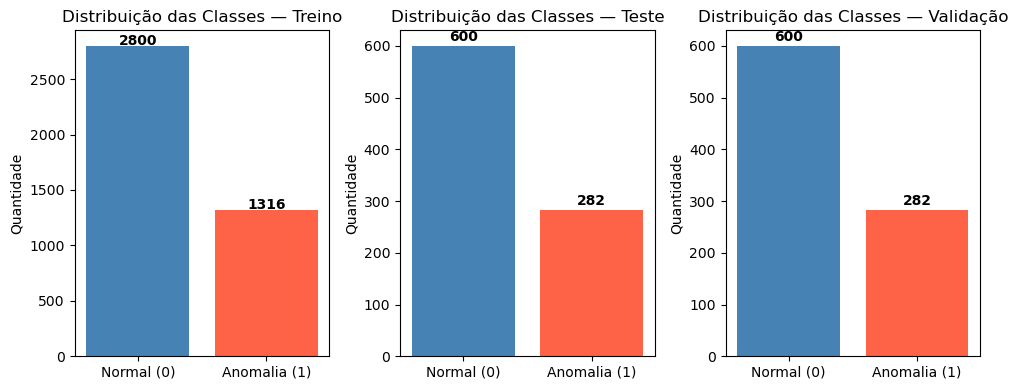

   X_train_scaled: (4116, 24)
   X_test_scaled:  (882, 24)
   X_val_scaled:  (882, 24)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
 
for ax, (data, title) in zip(axes, [
    (y_train, 'Treino'),
    (y_test,  'Teste'),
    (y_val, 'Validação')
]):
    counts = data.value_counts()
    ax.bar(['Normal (0)', 'Anomalia (1)'], counts.values,
           color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuição das Classes — {title}')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
 
plt.tight_layout()
plt.show()

print(f"   X_train_scaled: {X_train.shape}")
print(f"   X_test_scaled:  {X_test.shape}")
print(f"   X_val_scaled:  {X_val.shape}")

Conforme as informações obtidas pelo cálculo da regra de ouro, obtivemos que o número máximo de neurônios para a camada escondida é 15.

In [13]:
model = Sequential()

model.add(Input(shape=(24,)))

model.add(Dense(15, kernel_initializer='he_uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='glorot_uniform', activation='sigmoid'))

initial_weights = model.get_weights()

sgd = optimizers.SGD(learning_rate=0.01)

model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy', 'AUC'])

print(model.summary())

E0000 00:00:1775104110.536647  388840 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775104110.537093  388875 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775104110.555553  388840 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │           375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391 (1.53 KB)

 Trainable params: 391 (1.53 KB)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
model.set_weights(initial_weights)

history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(X_val, y_val))

Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6251 - accuracy: 0.6550 - loss: 0.6420 - val_AUC: 0.6718 - val_accuracy: 0.7358 - val_loss: 0.5755
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7279 - accuracy: 0.7736 - loss: 0.5300 - val_AUC: 0.7515 - val_accuracy: 0.7868 - val_loss: 0.5098
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7850 - accuracy: 0.8049 - loss: 0.4806 - val_AUC: 0.7977 - val_accuracy: 0.8175 - val_loss: 0.4662
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - AUC: 0.8146 - accuracy: 0.8275 - loss: 0.4465 - val_AUC: 0.8251 - val_accuracy: 0.8322 - val_loss: 0.4345
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8338 - accuracy: 0.8418 - loss: 0.4217 - val_AUC: 0.8445 - val_accuracy: 0.8401 - val_loss: 0.4112
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8475 - accuracy: 0.8494 - loss: 0.4030 - val_AUC: 0.8568 - val_accuracy: 0.8503 - val_loss: 0.3921
Epoch 7/100
258/258 ━━━━━━━━━━━━

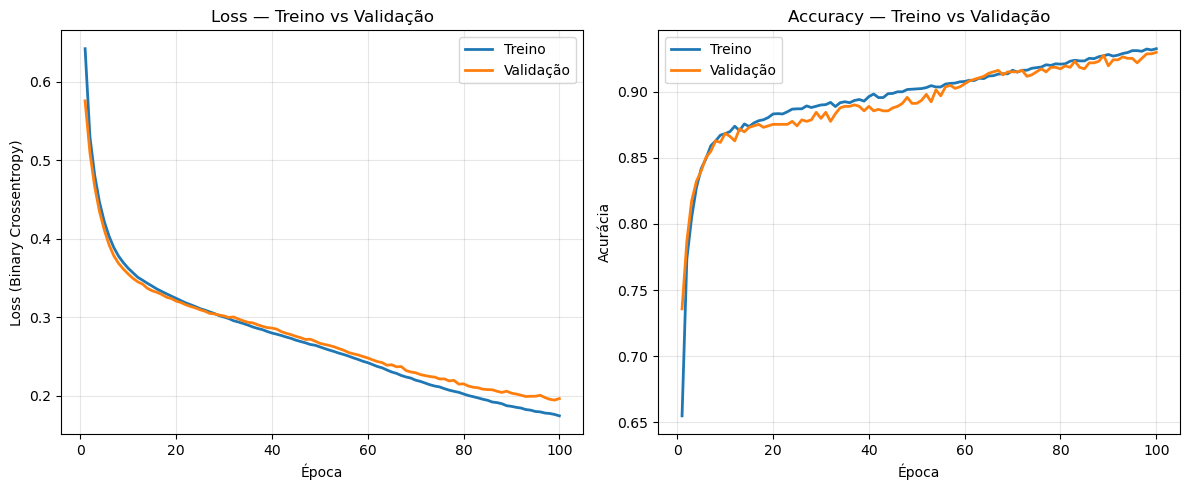


Menor val_loss em: época 99
Loss treino: 0.1760
Loss validação: 0.1943

Overfitting detectado a partir da época 99


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Loss
ein  = history.history['loss']
eout = history.history.get('val_loss')  # evita erro

epocas = range(1, len(ein) + 1)

plt.figure(figsize=(12, 5))

# --- LOSS ---
plt.subplot(1, 2, 1)
plt.plot(epocas, ein, label='Treino', linewidth=2)
if eout is not None:
    plt.plot(epocas, eout, label='Validação', linewidth=2)

plt.xlabel('Época')
plt.ylabel('Loss (Binary Crossentropy)')
plt.title('Loss — Treino vs Validação')
plt.legend()
plt.grid(alpha=0.3)

# --- ACCURACY ---
acc  = history.history.get('accuracy')
val_acc = history.history.get('val_accuracy')

plt.subplot(1, 2, 2)
if acc is not None:
    plt.plot(epocas, acc, label='Treino', linewidth=2)
if val_acc is not None:
    plt.plot(epocas, val_acc, label='Validação', linewidth=2)

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Accuracy — Treino vs Validação')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# DETECÇÃO DE OVERFITTING
# -----------------------------
if eout is not None:
    melhor_epoca = int(np.argmin(eout)) + 1

    print(f"\nMenor val_loss em: época {melhor_epoca}")
    print(f"Loss treino: {ein[melhor_epoca-1]:.4f}")
    print(f"Loss validação: {eout[melhor_epoca-1]:.4f}")

    if eout[-1] > eout[melhor_epoca-1]:
        print(f"\nOverfitting detectado a partir da época {melhor_epoca}")
    else:
        print(f"\nSem overfitting evidente")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
=== Métricas da Rede Neural ===
              precision    recall  f1-score   support

  Normal (0)       0.92      0.99      0.95       600
Anomalia (1)       0.97      0.81      0.88       282

    accuracy                           0.93       882
   macro avg       0.94      0.90      0.92       882
weighted avg       0.93      0.93      0.93       882



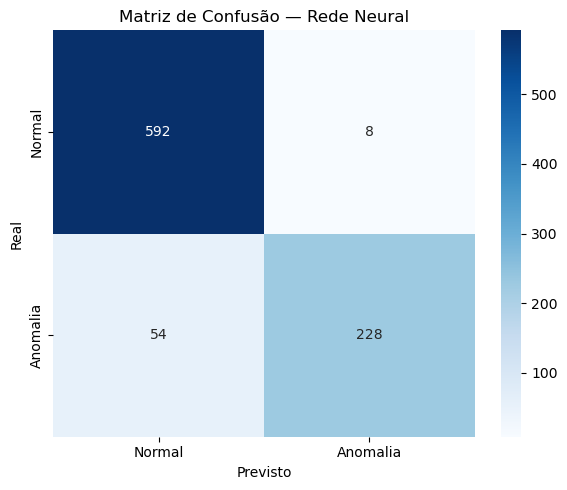

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# Predições na validação
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Métricas
print("=== Métricas da Rede Neural ===")
print(classification_report(y_val, y_pred,
      target_names=['Normal (0)', 'Anomalia (1)']))

# Matriz de confusão
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão — Rede Neural')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

Observando os valores das métricas das últimas 20 épocas.

Notamos que o modelo ainda estava aprendendo, com leves acréscimos nas métricas

Além disso, por se tratar de classificações sobre anomalidades em células sanguíneas onde um paciente poderia estar com uma das seguintes doenças:

- Leucemia
- Anemia
- Anemia falciforme
- Infecção
- Artefatos 

Observando a matriz de confusão achamos muitas classificações de falsos negativos.

Por exemplo, o modelo informava que o paciente estava bem, quando na verdade ele poderia estar com leucemia.

Decidimos testar com 200 épocas e utilizar balanceando das classes utilizando o `class_weight`, que penaliza mais os erros na classe minoritária durante o treino, onde a classe 0 ficaria com peso 1 e a classe 1 ficaria com peso 2.

In [17]:
model.set_weights(initial_weights)

history = model.fit(X_train, y_train, epochs=200, batch_size=16,
                   validation_data=(X_val, y_val), class_weight={0: 1.0, 1: 2.0})

Epoch 1/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6624 - accuracy: 0.5957 - loss: 0.8686 - val_AUC: 0.7221 - val_accuracy: 0.6950 - val_loss: 0.5911
Epoch 2/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7797 - accuracy: 0.7359 - loss: 0.7217 - val_AUC: 0.8006 - val_accuracy: 0.7562 - val_loss: 0.5283
Epoch 3/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - AUC: 0.8274 - accuracy: 0.7867 - loss: 0.6525 - val_AUC: 0.8386 - val_accuracy: 0.7902 - val_loss: 0.4796
Epoch 4/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - AUC: 0.8507 - accuracy: 0.8030 - loss: 0.6080 - val_AUC: 0.8613 - val_accuracy: 0.7959 - val_loss: 0.4521
Epoch 5/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8630 - accuracy: 0.8081 - loss: 0.5789 - val_AUC: 0.8717 - val_accuracy: 0.8186 - val_loss: 0.4166
Epoch 6/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8710 - accuracy: 0.8222 - loss: 0.5586 - val_AUC: 0.8770 - val_accuracy: 0.8220 - val_loss: 0.4058
Epoch 7/200
258/258 ━━━━━━━━━━

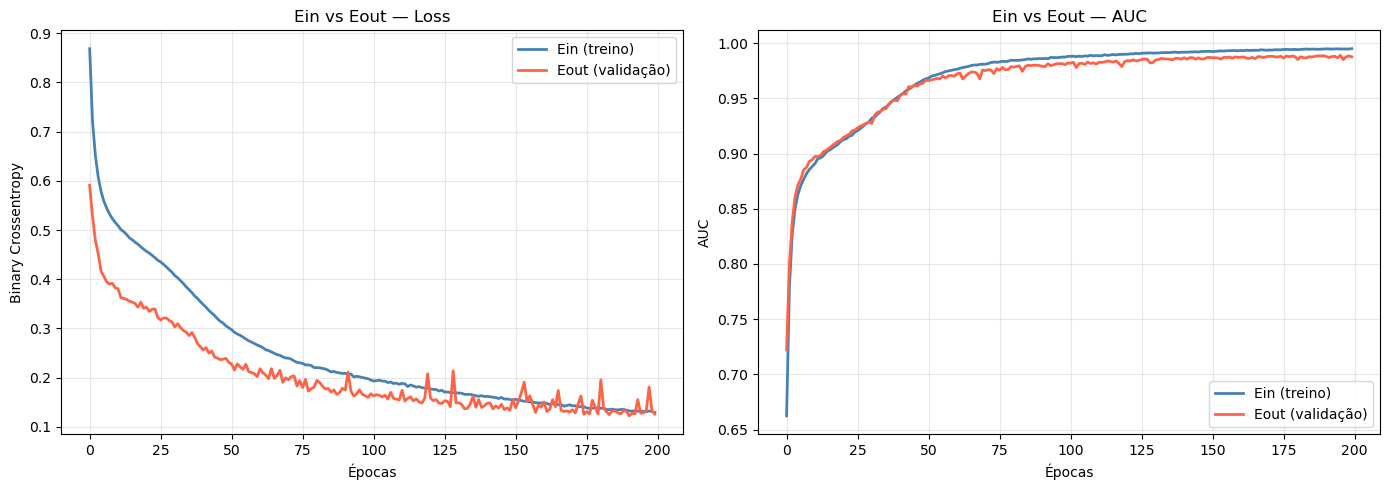


Melhor época (menor val_loss): 191
val_loss nessa época: 0.1224
loss nessa época:     0.1323

Época final (200):
  Ein  (loss treino):     0.1293
  Eout (loss validação):  0.1259
  Diferença Eout - Ein:   -0.0034
Sem overfitting significativo.


In [18]:
# -------------------------------------------------------------
# GRÁFICO Ein vs Eout (Loss e AUC por época)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(history.history['loss'],     label='Ein (treino)',     color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Eout (validação)', color='tomato',    linewidth=2)
axes[0].set_title('Ein vs Eout — Loss')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- AUC ---
axes[1].plot(history.history['AUC'],     label='Ein (treino)',     color='steelblue', linewidth=2)
axes[1].plot(history.history['val_AUC'], label='Eout (validação)', color='tomato',    linewidth=2)
axes[1].set_title('Ein vs Eout — AUC')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# IDENTIFICAR PONTO DE OVERFITTING (se houver)
# -------------------------------------------------------------
val_loss = history.history['val_loss']
min_val_loss = min(val_loss)
best_epoch = val_loss.index(min_val_loss) + 1

print(f"\nMelhor época (menor val_loss): {best_epoch}")
print(f"val_loss nessa época: {min_val_loss:.4f}")
print(f"loss nessa época:     {history.history['loss'][best_epoch-1]:.4f}")

train_loss_final = history.history['loss'][-1]
val_loss_final   = history.history['val_loss'][-1]
diff = val_loss_final - train_loss_final

print(f"\nÉpoca final ({len(val_loss)}):")
print(f"  Ein  (loss treino):     {train_loss_final:.4f}")
print(f"  Eout (loss validação):  {val_loss_final:.4f}")
print(f"  Diferença Eout - Ein:   {diff:.4f}")

if diff > 0.05:
    print("Possível overfitting detectado.")
else:
    print("Sem overfitting significativo.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step
=== Métricas da Rede Neural ===
              precision    recall  f1-score   support

  Normal (0)       0.97      0.96      0.97       600
Anomalia (1)       0.92      0.94      0.93       282

    accuracy                           0.96       882
   macro avg       0.95      0.95      0.95       882
weighted avg       0.96      0.96      0.96       882



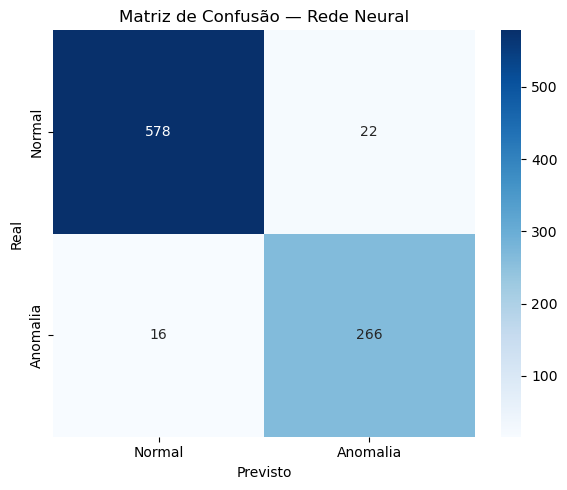

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# Predições na validação
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Métricas
print("=== Métricas da Rede Neural ===")
print(classification_report(y_val, y_pred,
      target_names=['Normal (0)', 'Anomalia (1)']))

# Matriz de confusão
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão — Rede Neural')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

Após a adição da penalização dos erros na classe minoritária e de mais 100 épocas, confirma-se o previsto, com 100 épocas o modelo ainda estava aprendendo.

Além disso, com a penalização, conseguimos aumentar o recall de anomalias de 81% para 94%, reduzimos a quantidade de falsos negativos de 54 para 16.

Tivemos um trade-off aceitável. A precisão de anomalias caiu de 97% para 92%, e os falsos positivos subiram de 8 para 22.

Em contextos clínicos, é justificável, afinal classificar pacientes com células doentes como saudáveis é muito mais grave do que o contrário, onde o paciente apenas passaria por mais exames.

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# -------------------------------------------------------------
# ETAPA 1 — Árvore sem restrições (sem poda)
# -------------------------------------------------------------
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# Ein e Eout
ein_tree  = 1 - tree_full.score(X_train, y_train)
eout_tree = 1 - tree_full.score(X_val,   y_val)

print(f"Árvore sem poda:")
print(f"  Profundidade máxima: {tree_full.get_depth()}")
print(f"  Número de folhas:    {tree_full.get_n_leaves()}")
print(f"  Ein  (treino):       {ein_tree:.4f}")
print(f"  Eout (validação):    {eout_tree:.4f}")
print(f"  Diferença:           {eout_tree - ein_tree:.4f}")

Árvore sem poda:
  Profundidade máxima: 24
  Número de folhas:    178
  Ein  (treino):       0.0000
  Eout (validação):    0.0680
  Diferença:           0.0680


Número de alphas candidatos: 104
Range de alpha: 0.000000 até 0.046558

Melhor alpha: 0.001847
Acurácia CV:  0.9342 ± 0.0012


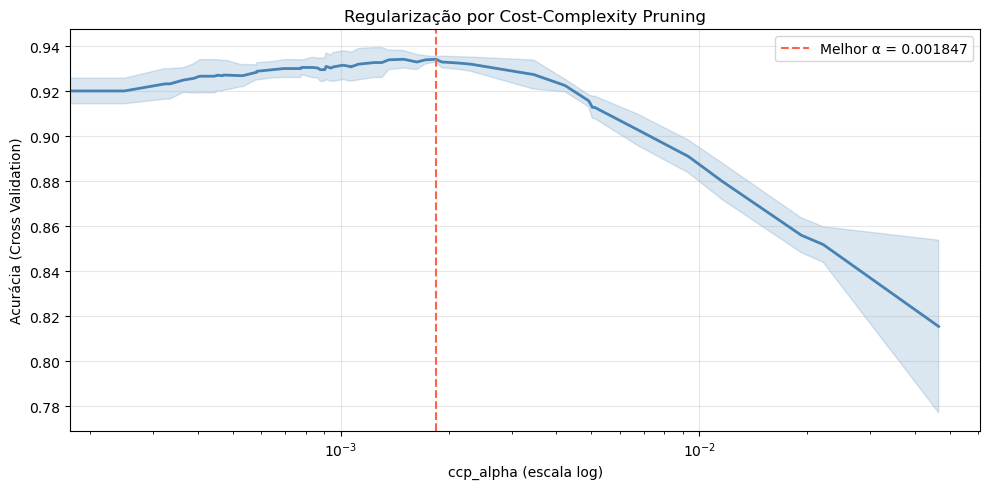

In [21]:
from sklearn.model_selection import cross_val_score

# -------------------------------------------------------------
# ETAPA 2 — Minimal Cost-Complexity Pruning
# -------------------------------------------------------------

# Obter os valores candidatos de alpha
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # remove o último (árvore vazia)

print(f"Número de alphas candidatos: {len(ccp_alphas)}")
print(f"Range de alpha: {ccp_alphas.min():.6f} até {ccp_alphas.max():.6f}")

# Cross Validation para cada alpha
# O fold é definido pela dimensão do conjunto de treino
# Usamos k=5 (padrão robusto e bem justificável)
k = 5
scores_mean = []
scores_std  = []

for alpha in ccp_alphas:
    tree_cv = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(tree_cv, X_train, y_train,
                             cv=k, scoring='accuracy')
    scores_mean.append(scores.mean())
    scores_std.append(scores.std())

scores_mean = np.array(scores_mean)
scores_std  = np.array(scores_std)

# Melhor alpha
best_idx   = scores_mean.argmax()
best_alpha = ccp_alphas[best_idx]

print(f"\nMelhor alpha: {best_alpha:.6f}")
print(f"Acurácia CV:  {scores_mean[best_idx]:.4f} ± {scores_std[best_idx]:.4f}")

# Gráfico alpha vs acurácia
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, scores_mean, color='steelblue', linewidth=2)
plt.fill_between(ccp_alphas,
                 scores_mean - scores_std,
                 scores_mean + scores_std,
                 alpha=0.2, color='steelblue')
plt.axvline(best_alpha, color='tomato', linestyle='--',
            label=f'Melhor α = {best_alpha:.6f}')
plt.xscale('log')
plt.xlabel('ccp_alpha (escala log)')
plt.ylabel('Acurácia (Cross Validation)')
plt.title('Regularização por Cost-Complexity Pruning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Árvore regularizada (α = 0.001847):
  Profundidade máxima: 12
  Número de folhas:    27
  Ein  (treino):       0.0491
  Eout (validação):    0.0760
  Diferença:           0.0269

=== Métricas da Árvore de Decisão ===
              precision    recall  f1-score   support

  Normal (0)       0.93      0.96      0.95       600
Anomalia (1)       0.91      0.84      0.88       282

    accuracy                           0.92       882
   macro avg       0.92      0.90      0.91       882
weighted avg       0.92      0.92      0.92       882



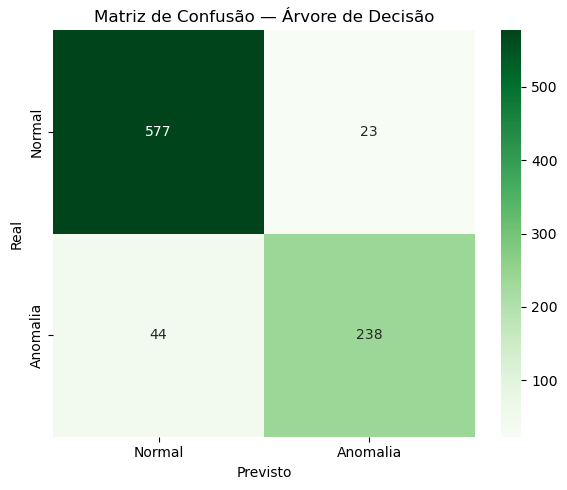

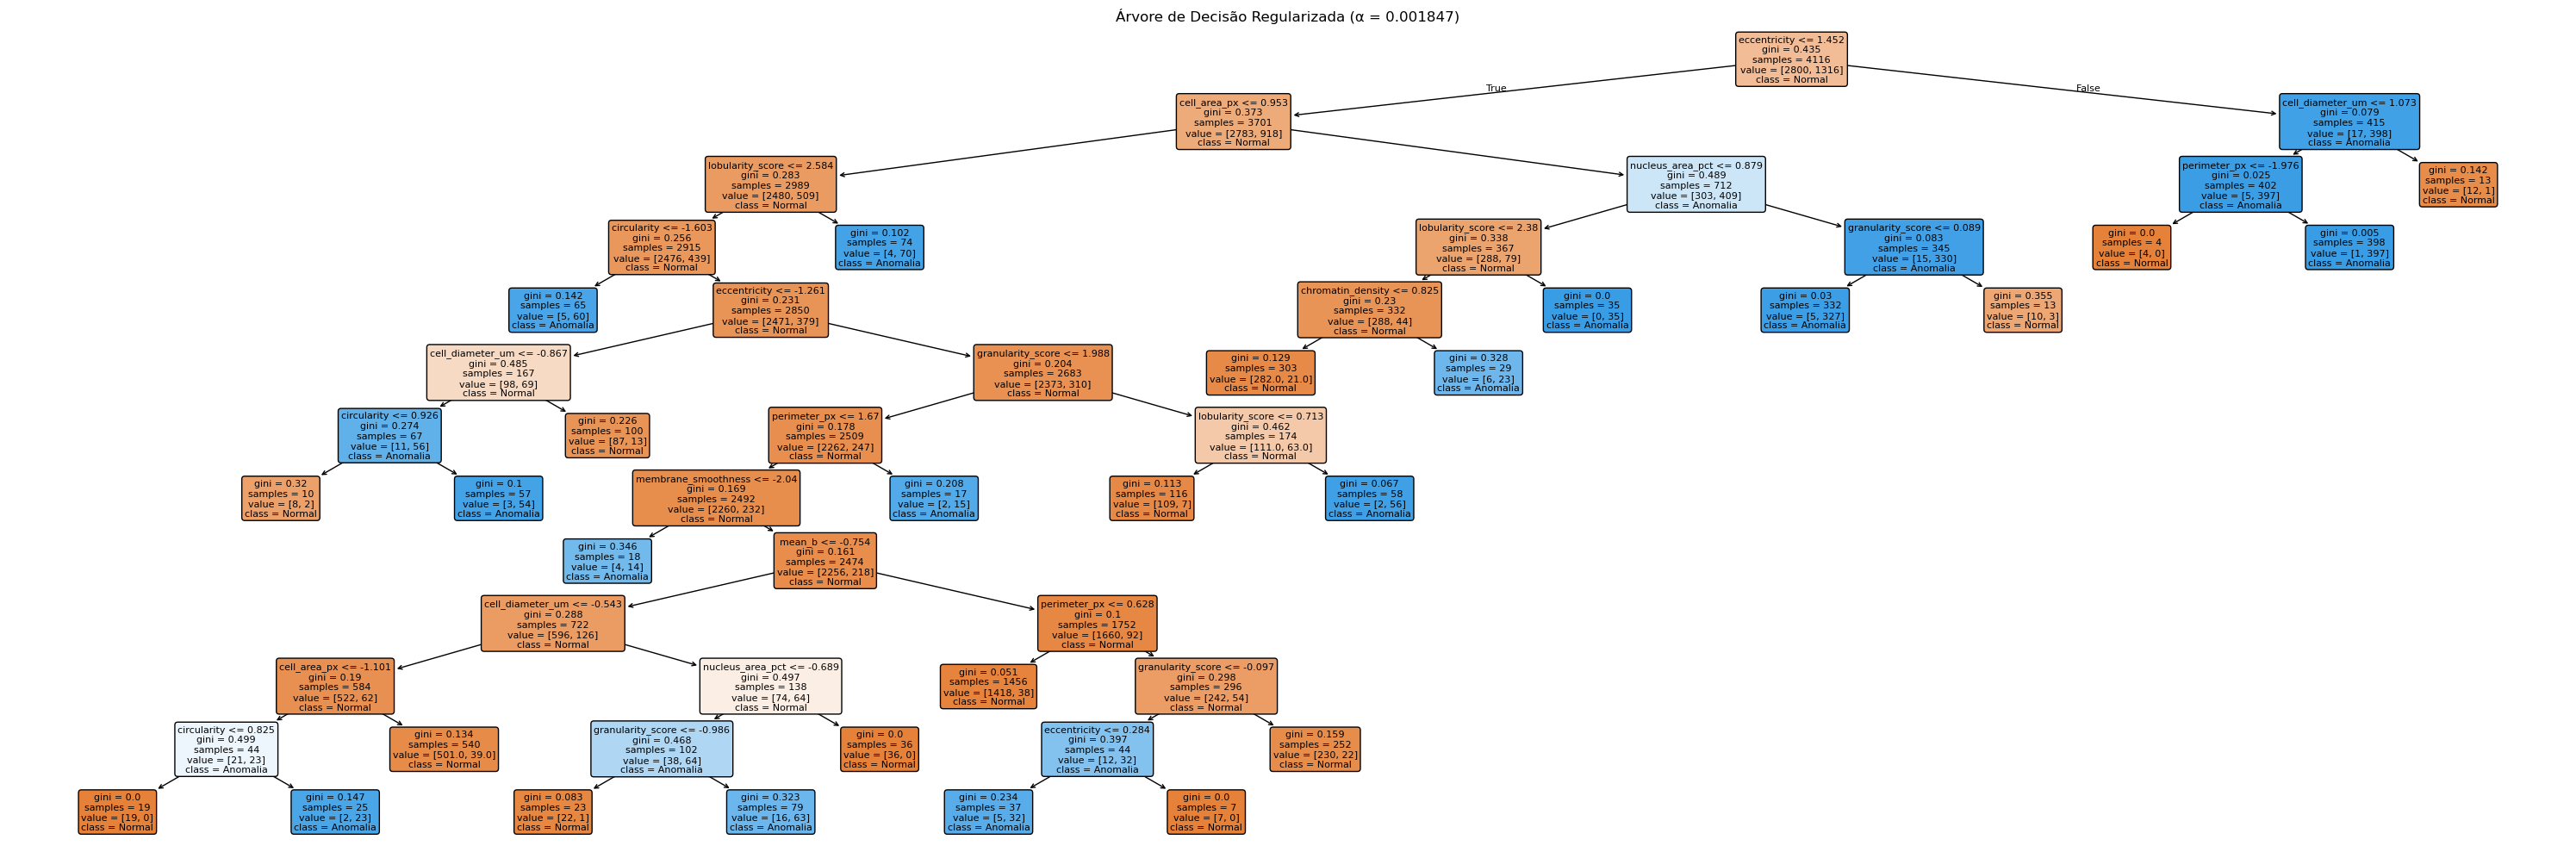

In [22]:
# -------------------------------------------------------------
# ETAPA 3 — Melhor árvore com alpha regularizado
# -------------------------------------------------------------
tree_best = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
tree_best.fit(X_train, y_train)

ein_best  = 1 - tree_best.score(X_train, y_train)
eout_best = 1 - tree_best.score(X_val,   y_val)

print(f"Árvore regularizada (α = {best_alpha:.6f}):")
print(f"  Profundidade máxima: {tree_best.get_depth()}")
print(f"  Número de folhas:    {tree_best.get_n_leaves()}")
print(f"  Ein  (treino):       {ein_best:.4f}")
print(f"  Eout (validação):    {eout_best:.4f}")
print(f"  Diferença:           {eout_best - ein_best:.4f}")

# -------------------------------------------------------------
# MÉTRICAS FINAIS
# -------------------------------------------------------------
y_pred_tree = tree_best.predict(X_val)

print("\n=== Métricas da Árvore de Decisão ===")
print(classification_report(y_val, y_pred_tree,
      target_names=['Normal (0)', 'Anomalia (1)']))

# Matriz de confusão
cm_tree = confusion_matrix(y_val, y_pred_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão — Árvore de Decisão')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# PLOTAR A ÁRVORE
# -------------------------------------------------------------
plt.figure(figsize=(30, 10))
plot_tree(tree_best,
          feature_names=X.columns.tolist(),
          class_names=['Normal', 'Anomalia'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title(f'Árvore de Decisão Regularizada (α = {best_alpha:.6f})')
plt.tight_layout()
plt.show()

Novamente obtivemos um valor consideravelmente alto de falsos negativos vamos tentar melhorar utilizando novamente a `class_weight`com "balanced"

Árvore regularizada com class_weight (α = 0.001847):
  Profundidade máxima: 10
  Número de folhas:    30
  Ein  (treino):       0.0449
  Eout (validação):    0.0669
  Diferença:           0.0219

Métricas da Árvore de Decisão (class_weight balanced)
              precision    recall  f1-score   support

  Normal (0)       0.95      0.95      0.95       600
Anomalia (1)       0.89      0.90      0.90       282

    accuracy                           0.93       882
   macro avg       0.92      0.93      0.92       882
weighted avg       0.93      0.93      0.93       882



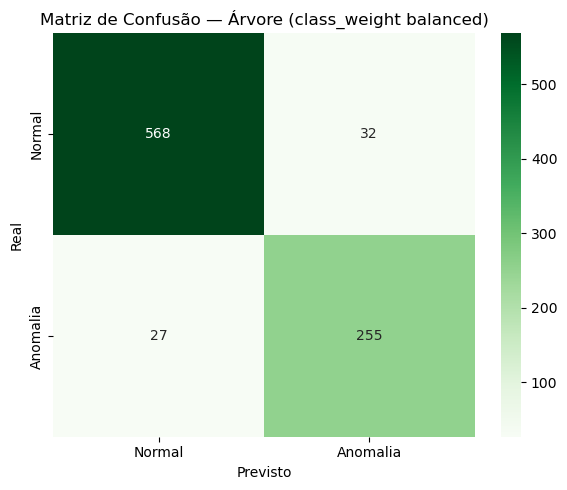

In [23]:
tree_best = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    class_weight='balanced',
    random_state=42
)
tree_best.fit(X_train, y_train)

ein_best  = 1 - tree_best.score(X_train, y_train)
eout_best = 1 - tree_best.score(X_val,   y_val)

print(f"Árvore regularizada com class_weight (α = {best_alpha:.6f}):")
print(f"  Profundidade máxima: {tree_best.get_depth()}")
print(f"  Número de folhas:    {tree_best.get_n_leaves()}")
print(f"  Ein  (treino):       {ein_best:.4f}")
print(f"  Eout (validação):    {eout_best:.4f}")
print(f"  Diferença:           {eout_best - ein_best:.4f}")

y_pred_tree = tree_best.predict(X_val)

print("\nMétricas da Árvore de Decisão (class_weight balanced)")
print(classification_report(y_val, y_pred_tree,
      target_names=['Normal (0)', 'Anomalia (1)']))

cm_tree = confusion_matrix(y_val, y_pred_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão — Árvore (class_weight balanced)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

O `class_weight='balanced'` melhorou em todos os aspectos relevantes. O recall de anomalias subiu de 84% para 90%, os falsos negativos caíram de 44 para 27, e o Eout melhorou de 0.076 para 0.067.

Com uma leve perda na precisão de 91% para 89%.

Agora para o SVM, seguindo o padrão nos modelos anteriores, onde o balancemento de classes melhorou significativamente o recall das anomalias. Decidimos treinar já com o `class_weight`

In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# -------------------------------------------------------------
# ETAPA 1 — Regularização de C e gamma via Cross Validation
# -------------------------------------------------------------
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='recall',  # priorizamos recall para anomalias
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros: {grid_search.best_params_}")
print(f"Melhor recall CV:    {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Melhores parâmetros: {'C': 100, 'gamma': 0.01}
Melhor recall CV:    0.8556


Melhor SVM (C=100, γ=0.01):
  Número de vetores de suporte: 1052
  Total de exemplos treino:     4116
  Ein  (treino):                0.0287
  Eout (validação):             0.0612
  Eout esperado (SVs/N):        0.2556
  Diferença Eout - Ein:         0.0326

=== Métricas do SVM ===
              precision    recall  f1-score   support

  Normal (0)       0.95      0.96      0.96       600
Anomalia (1)       0.92      0.89      0.90       282

    accuracy                           0.94       882
   macro avg       0.93      0.92      0.93       882
weighted avg       0.94      0.94      0.94       882



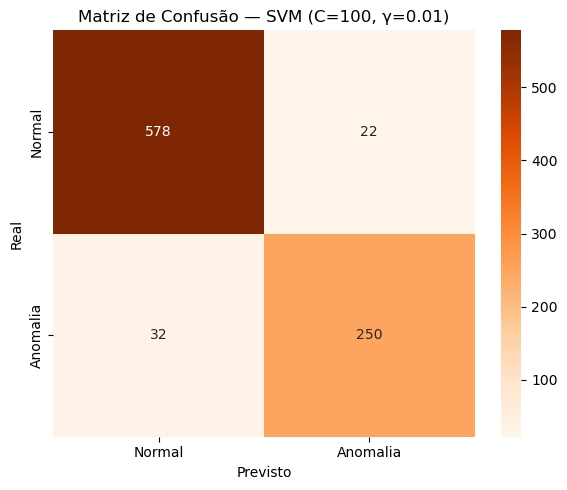

In [25]:
# -------------------------------------------------------------
# ETAPA 2 — Treinar melhor SVM e calcular Ein, Eout e Eout esperado
# -------------------------------------------------------------
best_svm = SVC(
    kernel='rbf',
    C=grid_search.best_params_['C'],
    gamma=grid_search.best_params_['gamma'],
    class_weight='balanced',
    random_state=42
)
best_svm.fit(X_train, y_train)

# Ein e Eout
ein_svm  = 1 - best_svm.score(X_train, y_train)
eout_svm = 1 - best_svm.score(X_val,   y_val)

# Eout esperado baseado nos vetores de suporte
n_support = best_svm.n_support_.sum()  # total de vetores de suporte
eout_esperado = n_support / len(X_train)

print(f"Melhor SVM (C={grid_search.best_params_['C']}, γ={grid_search.best_params_['gamma']}):")
print(f"  Número de vetores de suporte: {n_support}")
print(f"  Total de exemplos treino:     {len(X_train)}")
print(f"  Ein  (treino):                {ein_svm:.4f}")
print(f"  Eout (validação):             {eout_svm:.4f}")
print(f"  Eout esperado (SVs/N):        {eout_esperado:.4f}")
print(f"  Diferença Eout - Ein:         {eout_svm - ein_svm:.4f}")

# -------------------------------------------------------------
# ETAPA 3 — Métricas finais
# -------------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_svm = best_svm.predict(X_val)

print("\n=== Métricas do SVM ===")
print(classification_report(y_val, y_pred_svm,
      target_names=['Normal (0)', 'Anomalia (1)']))

cm_svm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title(f'Matriz de Confusão — SVM (C={grid_search.best_params_["C"]}, γ={grid_search.best_params_["gamma"]})')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

!pip install scikeras

In [26]:
import os
import logging

# Suprime warnings do TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # força uso da CPU

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
logging.getLogger('absl').setLevel('ERROR')


Avaliando Rede Neural...


I0000 00:00:1775104237.114571  406256 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775104237.114572  406264 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775104237.114572  406255 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775104237.117691  406266 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775104237.143709  406262 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775104237.152320  406264 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775104237.152497  406256 cpu_feature_guard.cc:227] This TensorFlow binar

  Acurácia: 0.9346 ± 0.0061
  Recall:   0.8898 ± 0.0286
  F1:       0.8965 ± 0.0101

Avaliando Árvore de Decisão...
  Acurácia: 0.9349 ± 0.0087
  Recall:   0.9020 ± 0.0199
  F1:       0.8986 ± 0.0131

Avaliando SVM...
  Acurácia: 0.9261 ± 0.0064
  Recall:   0.8556 ± 0.0200
  F1:       0.8812 ± 0.0081


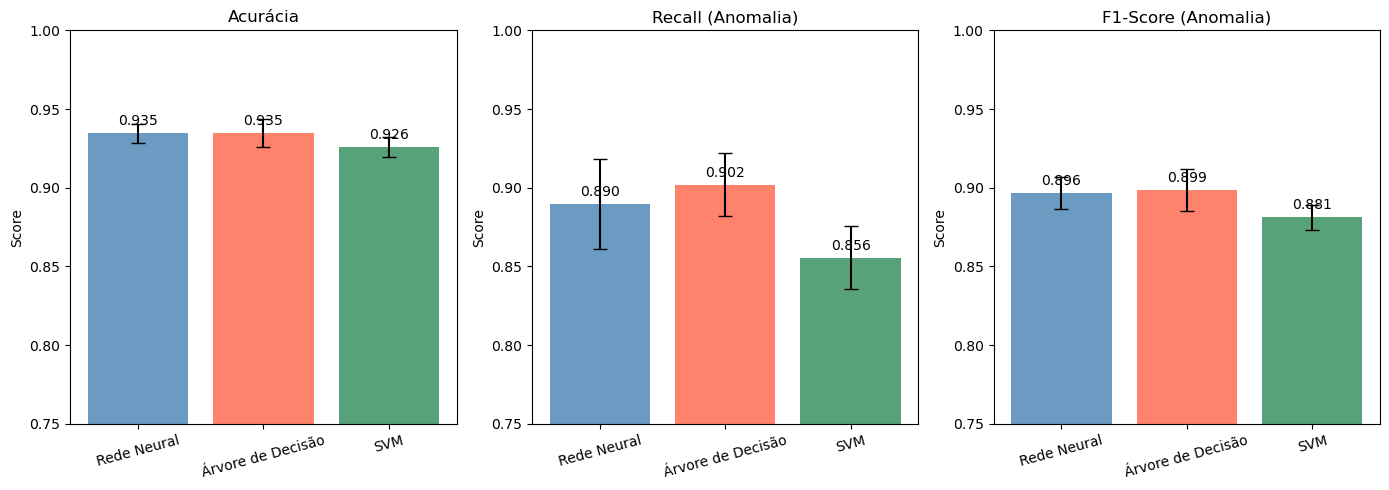


=== Decisão Final ===
Melhor em Acurácia:        Árvore de Decisão
Melhor em Recall Anomalia: Árvore de Decisão
Melhor em F1 Anomalia:     Árvore de Decisão

Modelo escolhido para avaliação no teste: Árvore de Decisão


In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scikeras.wrappers import KerasClassifier
from sklearn.pipeline import Pipeline

# -------------------------------------------------------------
# PONTO 4.5 — Escolha formal do melhor modelo via Cross Validation
# -------------------------------------------------------------
# Usamos StratifiedKFold para manter a proporção das classes
# em cada fold — essencial dado o desbalanceamento 68%/32%
# Usamos o conjunto de TREINO para a comparação (teste intocado)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def build_nn():
    model = Sequential()
    model.add(Input(shape=(24,)))
    model.add(Dense(15, kernel_initializer='he_uniform', activation='relu'))
    model.add(Dense(1, kernel_initializer='glorot_uniform', activation='sigmoid'))
    model.compile(optimizer=optimizers.SGD(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

modelos = {
    'Rede Neural': KerasClassifier(model=build_nn, epochs=200,
                                   batch_size=16, verbose=0,
                                   class_weight={0: 1.0, 1: 2.0}),
    'Árvore de Decisão': DecisionTreeClassifier(ccp_alpha=best_alpha,
                                                class_weight='balanced',
                                                random_state=42),
    'SVM': SVC(kernel='rbf', C=100, gamma=0.01,
               class_weight='balanced', random_state=42)
}

# -------------------------------------------------------------
# Cross Validation
# -------------------------------------------------------------
resultados = {}

for nome, modelo in modelos.items():
    print(f"\nAvaliando {nome}...")

    acc    = cross_val_score(modelo, X_train, y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    recall = cross_val_score(modelo, X_train, y_train,
                             cv=cv, scoring='recall', n_jobs=-1)
    f1     = cross_val_score(modelo, X_train, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)

    resultados[nome] = {'accuracy': acc, 'recall': recall, 'f1': f1}

    print(f"  Acurácia: {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"  Recall:   {recall.mean():.4f} ± {recall.std():.4f}")
    print(f"  F1:       {f1.mean():.4f} ± {f1.std():.4f}")

# -------------------------------------------------------------
# Gráfico comparativo
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metricas = ['accuracy', 'recall', 'f1']
titulos  = ['Acurácia', 'Recall (Anomalia)', 'F1-Score (Anomalia)']
cores    = ['steelblue', 'tomato', 'seagreen']

for ax, metrica, titulo in zip(axes, metricas, titulos):
    nomes  = list(resultados.keys())
    medias = [resultados[n][metrica].mean() for n in nomes]
    stds   = [resultados[n][metrica].std()  for n in nomes]

    bars = ax.bar(nomes, medias, yerr=stds, capsize=5,
                  color=cores, alpha=0.8)
    ax.set_title(titulo)
    ax.set_ylim(0.75, 1.0)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

    for bar, media in zip(bars, medias):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{media:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Decisão final
# -------------------------------------------------------------
melhor_recall = max(resultados, key=lambda n: resultados[n]['recall'].mean())
melhor_f1     = max(resultados, key=lambda n: resultados[n]['f1'].mean())
melhor_acc    = max(resultados, key=lambda n: resultados[n]['accuracy'].mean())

print(f"\n=== Decisão Final ===")
print(f"Melhor em Acurácia:        {melhor_acc}")
print(f"Melhor em Recall Anomalia: {melhor_recall}")
print(f"Melhor em F1 Anomalia:     {melhor_f1}")
print(f"\nModelo escolhido para avaliação no teste: {melhor_recall}")

=== Resultado Final no Conjunto de Teste ===
              precision    recall  f1-score   support

  Normal (0)       0.96      0.95      0.96       600
Anomalia (1)       0.89      0.92      0.91       282

    accuracy                           0.94       882
   macro avg       0.93      0.94      0.93       882
weighted avg       0.94      0.94      0.94       882



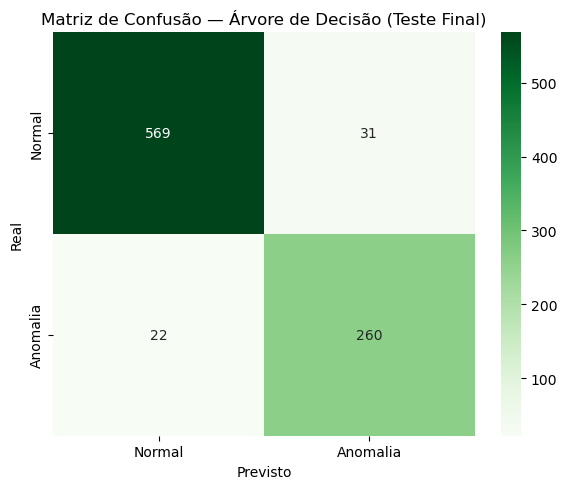

In [28]:
# -------------------------------------------------------------
# AVALIAÇÃO FINAL NO TESTE — Árvore de Decisão
# -------------------------------------------------------------
y_pred_final = tree_best.predict(X_test)

print("=== Resultado Final no Conjunto de Teste ===")
print(classification_report(y_test, y_pred_final,
      target_names=['Normal (0)', 'Anomalia (1)']))

cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão — Árvore de Decisão (Teste Final)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()